# BraTS 2021

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
flair = nib.load("BraTS2021_01163_flair.nii.gz").get_fdata()
t1 = nib.load("BraTS2021_01163_t1.nii.gz").get_fdata()
t1ce = nib.load("BraTS2021_01163_t1ce.nii.gz").get_fdata()
t2 = nib.load("BraTS2021_01163_t2.nii.gz").get_fdata()
seg = nib.load("BraTS2021_01163_seg.nii.gz").get_fdata()

In [ ]:
type(flair), flair.shape

(numpy.ndarray, (240, 240, 155))

In [ ]:
np.unique(seg)

array([0., 1., 2., 4.])

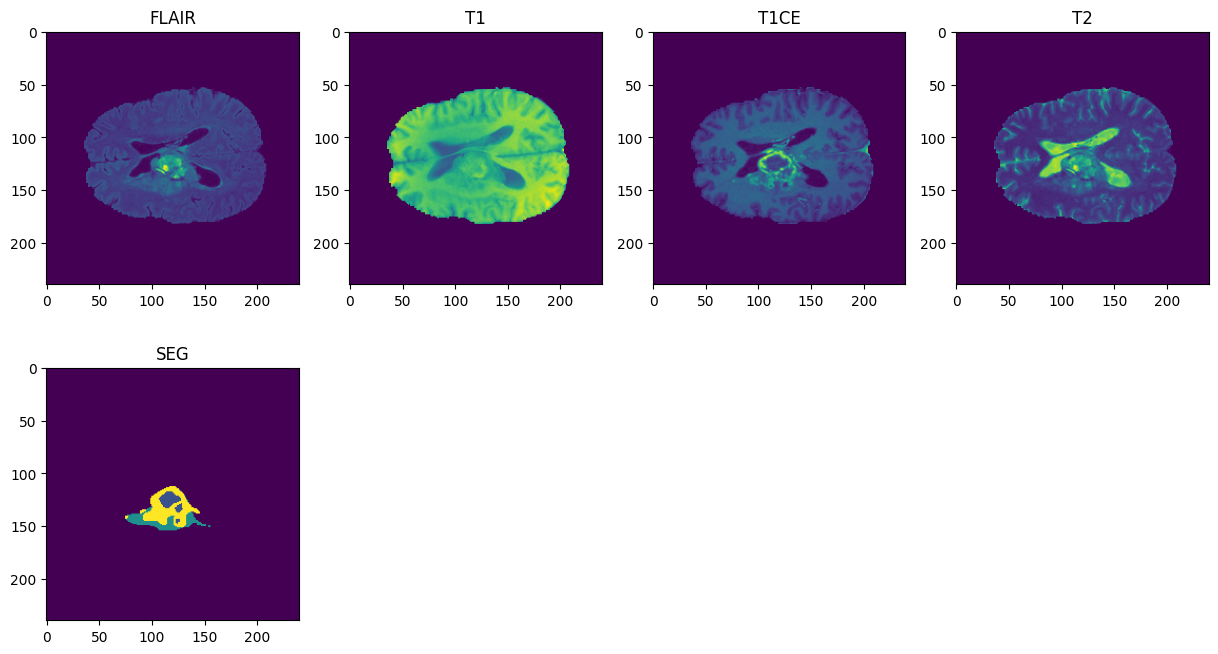

In [ ]:
slice_idx = 80

plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.imshow(flair[:,:,slice_idx])
plt.title("FLAIR")

plt.subplot(2,4,2)
plt.title("T1")
plt.imshow(t1[:,:,slice_idx])

plt.subplot(2,4,3)
plt.title("T1CE")
plt.imshow(t1ce[:,:,slice_idx])

plt.subplot(2,4,4)
plt.title("T2")
plt.imshow(t2[:,:,slice_idx])

plt.subplot(2,4,5)
plt.title("SEG")
plt.imshow(seg[:,:,slice_idx])


Text(0.5, 1.0, 'SEG')

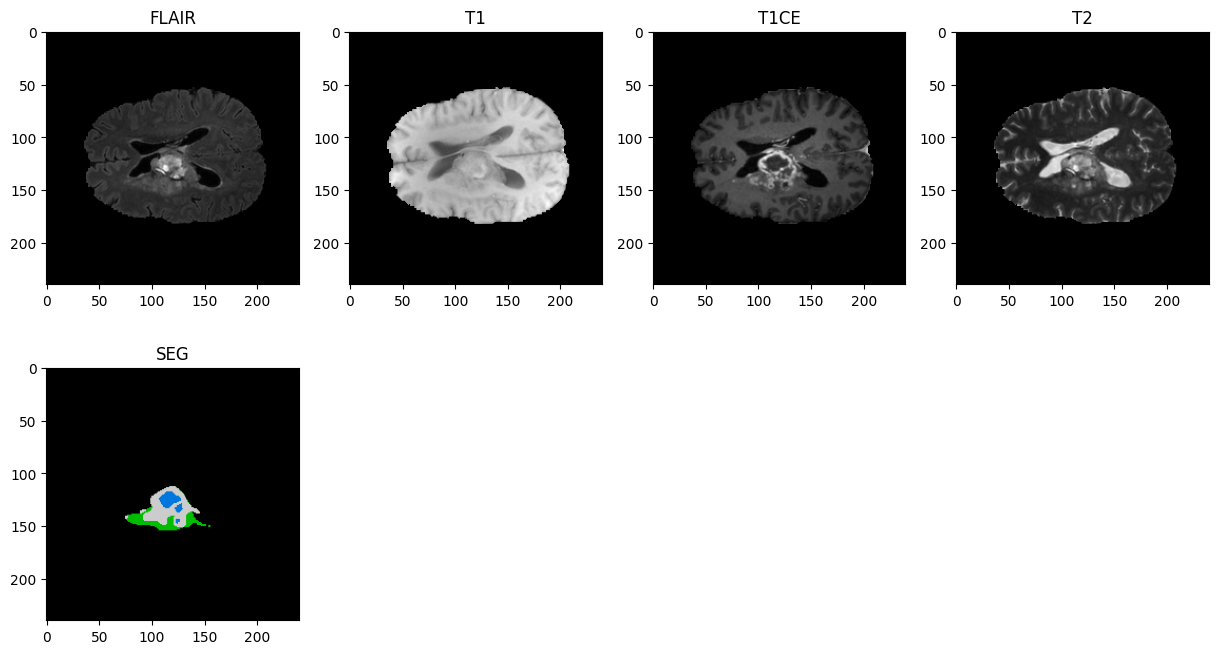

In [ ]:
slice_idx = 80

plt.figure(figsize=(15,8))

plt.subplot(2,4,1)
plt.imshow(flair[:,:,slice_idx], cmap="gray")
plt.title("FLAIR")

plt.subplot(2,4,2)
plt.imshow(t1[:,:,slice_idx], cmap="gray")
plt.title("T1")

plt.subplot(2,4,3)
plt.imshow(t1ce[:,:,slice_idx], cmap="gray")
plt.title("T1CE")

plt.subplot(2,4,4)
plt.imshow(t2[:,:,slice_idx], cmap="gray")
plt.title("T2")

plt.subplot(2,4,5)
plt.imshow(seg[:,:,slice_idx], cmap="nipy_spectral")
plt.title("SEG")

### What Each Image Represents

In medical imaging, particularly for brain MRI, different imaging modalities highlight various tissue contrasts, abnormalities, and tumor properties. Here's what each of the modalities in the BraTS dataset represents:

#### FLAIR (Fluid-Attenuated Inversion Recovery):
- Suppresses the signal from free water (like cerebrospinal fluid).
- Highlights abnormalities such as edema, which often surrounds tumors.
- Very useful for identifying lesions that are near or involve cerebrospinal fluid.

#### T1 (T1-Weighted MRI):
- Provides structural detail about normal brain anatomy.
- Tumors generally appear as hypointense (darker) regions in T1 images.
- Not as useful for visualizing tumor contrast directly without enhancement.

#### T1CE (Post-Contrast T1-Weighted MRI):
- Captures T1-weighted imaging after administering a contrast agent (e.g., gadolinium).
- Highlights areas where the blood-brain barrier is disrupted, such as enhancing tumor regions.
- Enhancing regions correspond to active tumor growth.

#### T2 (T2-Weighted MRI):
- Shows increased water content in tissues.
- Tumors and edema appear hyperintense (brighter).
- Complements FLAIR to identify tumor extent and distinguish different regions.

---

### BraTS Tumor Segmentation Mask Values

In the BraTS dataset, the segmentation mask contains voxel-wise labels corresponding to different tumor sub-regions:

| Label Value | Tumor Sub-Region                       | Description                                   |
|-------------|----------------------------------------|-----------------------------------------------|
| 0           | Background/Healthy Tissue             | No tumor present.                            |
| 1           | Necrotic tumor core | Dead tissue.      |
| 2           | Peritumoral Edema (ED)                | Swelling around the tumor.                   |
| 4           | Enhancing Tumor (ET)                  | Actively growing/contrast-enhancing tumor.   |

---

### Why Are Different Colors Appearing?

The `nipy_spectral` colormap maps these label values (0, 1, 2, 4) to distinct colors. The colors help visually differentiate the tumor sub-regions. For example:

- **Label 0 (Background):** Typically black or dark color (depending on the colormap).
- **Label 1 (NCR/NET):** Assigned one color (e.g., blue, red, or purple).
- **Label 2 (Edema):** Another distinct color (e.g., green or cyan).
- **Label 4 (Enhancing Tumor):** A bright color (e.g., yellow or orange).

These colors are purely for visualization and don’t carry inherent meaning beyond distinguishing the label values.

---

### How to Interpret the Colors

When visualizing the segmentation mask overlaid on an MRI slice, the colors indicate:

- **Blue/Purple/Other Color (Label 1):** Necrotic or non-enhancing tumor regions.
- **Green/Teal/Other Color (Label 2):** Swelling around the tumor.
- **Yellow/Orange/Other Color (Label 4):** Actively growing tumor regions.

#### For example:
- A **yellow patch (Label 4)** indicates the presence of an enhancing tumor.
- A **blue patch (Label 1)** indicates necrosis or non-enhancing tumor core.


In [ ]:
for slice_idx in range(flair.shape[2]):
    plt.figure(figsize=(10, 5))
    plt.imshow(flair[:, :, slice_idx], cmap="gray")
    plt.title(f"FLAIR - Slice {slice_idx}")
    plt.show()

In [ ]:
for slice_idx in range(seg.shape[2]):
    plt.figure(figsize=(10, 5))
    plt.imshow(seg[:, :, slice_idx], cmap="nipy_spectral")
    plt.title(f"Segmentation - Slice {slice_idx}")
    plt.show()

### What Does `slice_idx` Mean?

MRI data is stored as a 3D volume consisting of a stack of 2D slices. Each slice represents a cross-sectional image of the brain along a specific axis. The `slice_idx` refers to which 2D slice is extracted and visualized from the 3D data.

- In the code example, `slice_idx = 80` refers to the 80th slice in the selected axis (usually axial view by default).
- Axial view refers to cross-sectional slices taken from top to bottom of the brain.

### What Does `slice_idx` Mean?

MRI data is stored as a 3D volume consisting of a stack of 2D slices. Each slice represents a cross-sectional image of the brain along a specific axis. The `slice_idx` refers to which 2D slice is extracted and visualized from the 3D data.

- In the code example, `slice_idx = 80` refers to the 80th slice in the selected axis (usually axial view by default).
- Axial view refers to cross-sectional slices taken from top to bottom of the brain.

---

### Common Slices to Visualize

The most relevant slices for brain tumor studies usually lie in the middle region of the brain because:
- Tumors are often located in the cerebral hemispheres, closer to the center of the brain.
- Slices too close to the top or bottom of the brain may not show useful information.

---

### Typical Slice Ranges

#### Axial View (Top-to-Bottom):
- Slices around **60–100** often show the brain's central structures and tumors.

#### Coronal View (Front-to-Back):
- Middle slices highlight tumor spread across the lobes.

#### Sagittal View (Side-to-Side):
- Focuses on the left/right brain hemispheres and midline structures.


### Common Slices to Visualize

The most relevant slices for brain tumor studies usually lie in the middle region of the brain because:
- Tumors are often located in the cerebral hemispheres, closer to the center of the brain.
- Slices too close to the top or bottom of the brain may not show useful information.

---

### Typical Slice Ranges

#### Axial View (Top-to-Bottom):
- Slices around **60–100** often show the brain's central structures and tumors.

#### Coronal View (Front-to-Back):
- Middle slices highlight tumor spread across the lobes.

#### Sagittal View (Side-to-Side):
- Focuses on the left/right brain hemispheres and midline structures.


# MMIST ccRCC

**Scans** - pretty much same as previous.

**Genomic, Histopathology etc** - [Link](https://github.com/Multi-Modal-IST/multi-modal-ist.github.io/blob/master/datasets/ccRCC/Code)

# Conclusion

- Train the model on the given modalities of data.
- Add compelxity:
  - Aligning to preserve the 3d geometry.
  - Algining modalities.
  - Augmentations.
  - Multi label segmentation.
  - Robustness study.
  - Differential privacy.
  - Explainability & reporting module.
  - Complex/ Bigger models/ Architectures.
  - Ensembles.
  - Federated learning.